# US 4.1 — Modelo Base: XGBoost

Implementa XGBoost como modelo de *Machine Learning* baseline para la imputación de valores faltantes en series hidrometeorológicas de Sinaloa, siguiendo la arquitectura de modelos documentada en el proyecto.

## Estrategia de imputación
Los modelos de ML no son secuenciales de forma nativa, así que la imputación se hace mediante **regresión supervisada multivariada**:
- **Features:** lag temporales de cada variable (t-1, t-2, t-3, t-7, t-14), componentes de fecha (mes, día del año, día de la semana), medias móviles (7d, 30d), y las demás variables como covariables cruzadas.
- **Target:** la variable a imputar en el instante t.
- **Un modelo por variable** para preservar independencia en la evaluación.

## Evaluación MCAR
Se enmascara artificialmente el 20% de los valores observados del set de test y se mide el error sólo en esas posiciones.

## Métricas de evaluación
| Métrica | Descripción |
|---------|-------------|
| RMSE / MAE / MAPE | Error puntual en espacio escalado |
| R² / NSE | Bondad de ajuste global |
| KPSS | Estacionariedad: H₀ serie estacionaria — preservación de régimen temporal |
| ACF/PACF | Estructura de autocorrelación (21 lags): original vs imputado |

## Dependencias
```
pip install xgboost
```
Si no está instalado se usa `sklearn.ensemble.GradientBoostingRegressor` como fallback con la misma interfaz.

In [1]:
# Instalar XGBoost si no está disponible
!pip install xgboost --quiet

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
np.random.seed(42)

# ─── Raíz del proyecto ───────────────────────────────────────────────────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
REPORTS_DIR  = PROJECT_ROOT / "reports" / "modelos_base"
FIGURES_DIR  = REPORTS_DIR / "figuras"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

VARIABLES = ["precip", "evap", "tmax", "tmin"]
MCAR_RATE = 0.20
SEED = 42

# ─── XGBoost o fallback GradientBoosting ─────────────────────────────────────
try:
    from xgboost import XGBRegressor
    def make_model():
        return XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        )
    MODEL_NAME = "XGBoost"
    print("✓ XGBoost disponible")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    def make_model():
        return GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            random_state=SEED,
        )
    MODEL_NAME = "GradientBoosting (fallback)"
    print("⚠️  XGBoost no instalado. Usando GradientBoostingRegressor de sklearn.")
    print("   Instala XGBoost: pip install xgboost")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

✓ XGBoost disponible
PROJECT_ROOT: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main


## 1 — Carga de datos

In [3]:
df_train = pd.read_parquet(SPLITS_DIR / "train" / "train.parquet")
df_val   = pd.read_parquet(SPLITS_DIR / "val"   / "val.parquet")
df_test  = pd.read_parquet(SPLITS_DIR / "test"  / "test.parquet")

for df in [df_train, df_val, df_test]:
    df['date'] = pd.to_datetime(df['date'])

print(f"Train: {df_train.shape}  |  Val: {df_val.shape}  |  Test: {df_test.shape}")
print(f"Estaciones: {df_train['estacion'].nunique()}")
df_train.head(3)

Train: (1127704, 6)  |  Val: (241673, 6)  |  Test: (241741, 6)
Estaciones: 173


,estacion,date,precip,evap,tmax,tmin
0,25001,1961-01-01,0.0,NaN,-1.565546,-0.597976
1,25001,1961-01-02,0.0,NaN,-1.055423,-0.436848
2,25001,1961-01-03,0.0,NaN,-0.341250,-0.920232


## 2 — Feature engineering

In [4]:
def build_features(df: pd.DataFrame, target_var: str,
                   lag_days: list = [1, 2, 3, 7, 14, 30]) -> pd.DataFrame:
    """
    Construye features para predecir `target_var`.
    Las demás variables actúan como covariables en t.
    Se añaden lags del target, componentes de fecha y medias móviles.
    """
    other_vars = [v for v in VARIABLES if v != target_var]
    dfs = []

    for station, grp in df.groupby('estacion'):
        g = grp.sort_values('date').copy()

        # Componentes de fecha
        g['mes']         = g['date'].dt.month
        g['dia_anio']    = g['date'].dt.dayofyear
        g['dia_semana']  = g['date'].dt.dayofweek
        g['sin_dia']     = np.sin(2 * np.pi * g['dia_anio'] / 365.25)
        g['cos_dia']     = np.cos(2 * np.pi * g['dia_anio'] / 365.25)

        # Lags del target
        for lag in lag_days:
            g[f"{target_var}_lag{lag}"] = g[target_var].shift(lag)

        # Medias móviles del target
        for w in [7, 30]:
            g[f"{target_var}_roll{w}"] = (
                g[target_var].shift(1).rolling(w, min_periods=1).mean()
            )

        # Covariables contemporáneas de otras variables
        for ov in other_vars:
            g[f"{ov}_t0"]   = g[ov]
            g[f"{ov}_lag1"] = g[ov].shift(1)

        dfs.append(g)

    return pd.concat(dfs, ignore_index=True)


FEATURE_LAGS = [1, 2, 3, 7, 14, 30]
print("Feature engineering configurado.")
print(f"Lags del target: {FEATURE_LAGS}")
print(f"Covariables cruzadas: {VARIABLES}")

Feature engineering configurado.
Lags del target: [1, 2, 3, 7, 14, 30]
Covariables cruzadas: ['precip', 'evap', 'tmax', 'tmin']


In [5]:
def get_feature_cols(target_var: str) -> list:
    """Devuelve la lista de columnas de features para un target dado."""
    other = [v for v in VARIABLES if v != target_var]
    cols = ['mes', 'dia_anio', 'dia_semana', 'sin_dia', 'cos_dia']
    for lag in FEATURE_LAGS:
        cols.append(f"{target_var}_lag{lag}")
    for w in [7, 30]:
        cols.append(f"{target_var}_roll{w}")
    for ov in other:
        cols += [f"{ov}_t0", f"{ov}_lag1"]
    return cols


# Ejemplo: features para precip
print("Features para 'precip':")
print(get_feature_cols('precip'))

Features para 'precip':
['mes', 'dia_anio', 'dia_semana', 'sin_dia', 'cos_dia', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag7', 'precip_lag14', 'precip_lag30', 'precip_roll7', 'precip_roll30', 'evap_t0', 'evap_lag1', 'tmax_t0', 'tmax_lag1', 'tmin_t0', 'tmin_lag1']


## 3 — Entrenamiento y evaluación (MCAR)

In [6]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, var_name: str) -> dict:
    eps = 1e-8
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100)
    r2   = float(r2_score(y_true, y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    nse  = float(1 - ss_res / (ss_tot + eps))
    return {"variable": var_name, "rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "nse": nse}


xgb_results = []
models_fitted = {}

for var in VARIABLES:
    print(f"\n── {var.upper()} {'─'*40}")

    # Feature engineering para train+val (unimos para más datos)
    df_tv = pd.concat([df_train, df_val], ignore_index=True)
    df_tv_fe = build_features(df_tv, var, lag_days=FEATURE_LAGS)
    feat_cols = get_feature_cols(var)

    # Sólo filas donde el target es válido
    mask_valid = df_tv_fe[var].notna()
    X_tv = df_tv_fe.loc[mask_valid, feat_cols].copy()
    y_tv = df_tv_fe.loc[mask_valid, var].copy()

    # Rellenar NaN en features con mediana global de esa columna
    X_tv = X_tv.fillna(X_tv.median())

    print(f"  Train+Val: {len(X_tv):,} muestras válidas")

    model = make_model()
    model.fit(X_tv, y_tv)
    models_fitted[var] = model

    # ── Evaluación MCAR en test ───────────────────────────────────────────
    df_test_fe = build_features(df_test, var, lag_days=FEATURE_LAGS)
    feat_medians = X_tv.median()  # mediana del train para rellenar NaN en test
    X_test_all = df_test_fe[feat_cols].fillna(feat_medians)
    y_test_all = df_test_fe[var]

    # Posiciones observadas en test
    obs_mask = y_test_all.notna()
    obs_idx  = y_test_all[obs_mask].index

    # MCAR: enmascarar 20% de observados
    rng = np.random.default_rng(SEED)
    n_mask = max(1, int(len(obs_idx) * MCAR_RATE))
    mcar_idx = rng.choice(obs_idx, size=n_mask, replace=False)

    X_mcar = X_test_all.loc[mcar_idx]
    y_mcar_true = y_test_all.loc[mcar_idx].values
    y_mcar_pred = model.predict(X_mcar)

    m = compute_metrics(y_mcar_true, y_mcar_pred, var)
    m["modelo"] = MODEL_NAME
    m["n_mcar"] = n_mask
    xgb_results.append(m)

    print(f"  MCAR posiciones: {n_mask}")
    print(f"  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  MAPE={m['mape']:.2f}%  R²={m['r2']:.4f}  NSE={m['nse']:.4f}")


── PRECIP ────────────────────────────────────────
  Train+Val: 1,359,882 muestras válidas
  MCAR posiciones: 48075
  RMSE=0.0208  MAE=0.0069  MAPE=26593808.08%  R²=0.1394  NSE=0.1394

── EVAP ────────────────────────────────────────
  Train+Val: 863,993 muestras válidas
  MCAR posiciones: 24803
  RMSE=0.0559  MAE=0.0381  MAPE=181717.05%  R²=0.6891  NSE=0.6891

── TMAX ────────────────────────────────────────
  Train+Val: 1,262,070 muestras válidas
  MCAR posiciones: 47177
  RMSE=0.4183  MAE=0.3021  MAPE=88.28%  R²=0.8271  NSE=0.8271

── TMIN ────────────────────────────────────────
  Train+Val: 1,262,070 muestras válidas
  MCAR posiciones: 47177
  RMSE=0.2761  MAE=0.1986  MAPE=56.90%  R²=0.9265  NSE=0.9265


## 4 — Importancia de features

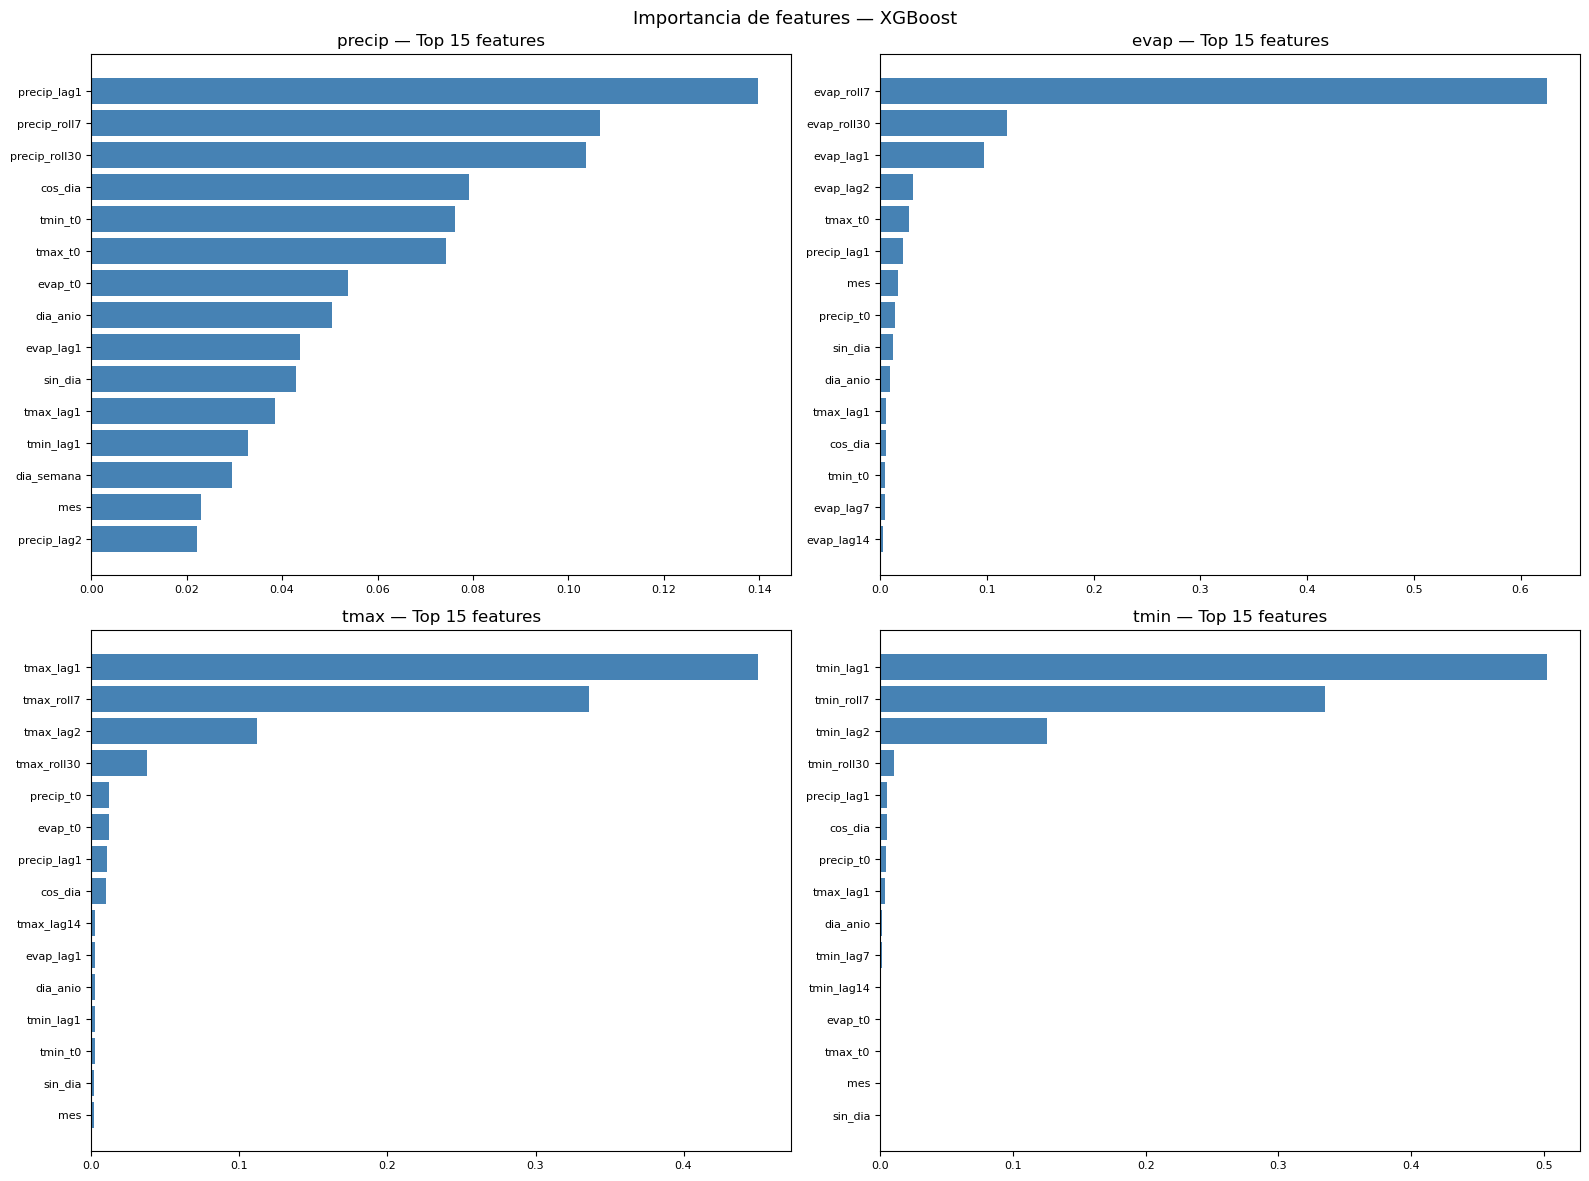

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Importancia de features — {MODEL_NAME}", fontsize=13)

for ax, var in zip(axes.flat, VARIABLES):
    model = models_fitted[var]
    feat_cols = get_feature_cols(var)

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = np.zeros(len(feat_cols))

    idx_sorted = np.argsort(importances)[::-1][:15]
    top_feats  = [feat_cols[i] for i in idx_sorted]
    top_imps   = importances[idx_sorted]

    ax.barh(top_feats[::-1], top_imps[::-1], color='steelblue')
    ax.set_title(f"{var} — Top 15 features")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_importancia_features.png", dpi=120, bbox_inches='tight')
plt.show()

## 5 — Visualización de imputaciones

Estación para visualización: 25081


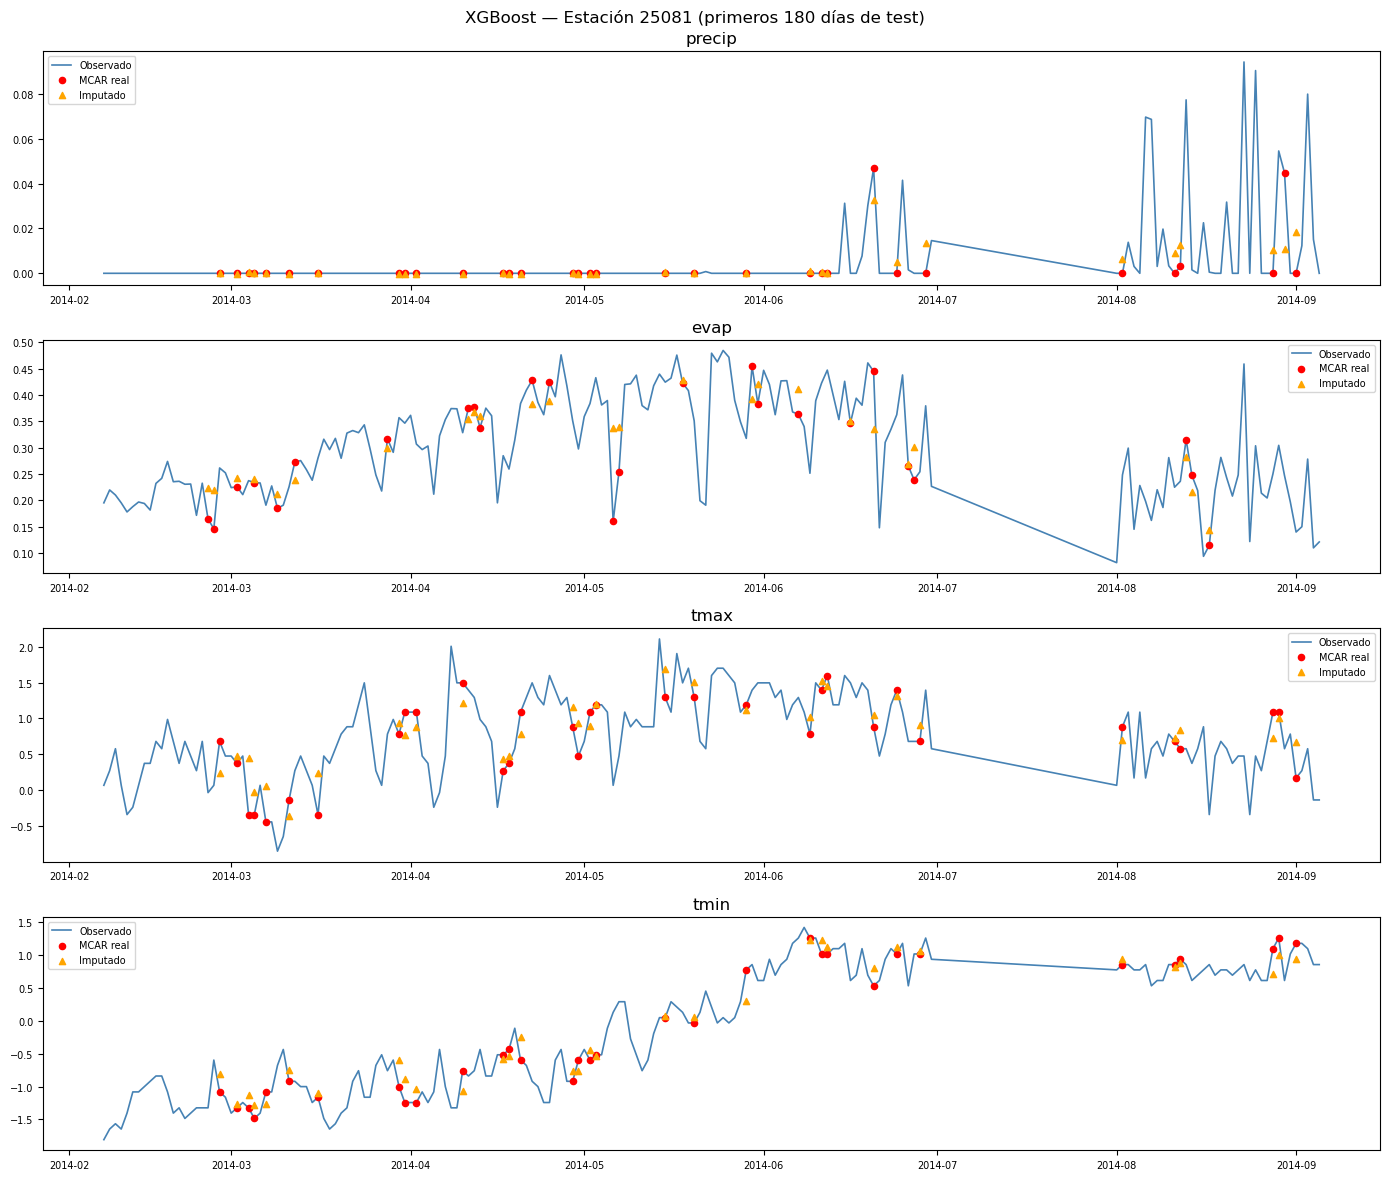

In [8]:
# Seleccionar estación con más datos en test para visualización
obs_counts = (
    df_test.groupby("estacion")[VARIABLES]
    .apply(lambda d: d.notna().all(axis=1).sum())
)
STATION = obs_counts.idxmax()
print(f"Estación para visualización: {STATION}")

test_st = df_test[df_test["estacion"] == STATION].sort_values('date')

fig, axes = plt.subplots(len(VARIABLES), 1, figsize=(14, 3*len(VARIABLES)))
fig.suptitle(f"{MODEL_NAME} — Estación {STATION} (primeros 180 días de test)", fontsize=12)

for ax, var in zip(axes, VARIABLES):
    model = models_fitted[var]
    feat_cols = get_feature_cols(var)

    # Feature engineering en la estación de test
    df_test_fe_st = build_features(test_st, var, lag_days=FEATURE_LAGS)
    X_st = df_test_fe_st[feat_cols].fillna(df_test_fe_st[feat_cols].median())
    y_st = df_test_fe_st[var]

    obs_idx = y_st.dropna().index
    rng = np.random.default_rng(SEED)
    n_mask = max(1, int(len(obs_idx) * MCAR_RATE))
    mcar_idx = rng.choice(obs_idx, size=n_mask, replace=False)

    preds = model.predict(X_st.loc[mcar_idx])

    # Límite de 180 días
    dates = df_test_fe_st['date'].values
    cut = dates[:180]
    in_seg = [i for i in mcar_idx if df_test_fe_st.loc[i, 'date'] in cut]

    ax.plot(df_test_fe_st['date'].iloc[:180],
            y_st.iloc[:180].values, 'steelblue', lw=1.2, label='Observado')

    if in_seg:
        mcar_dates = df_test_fe_st.loc[in_seg, 'date']
        ax.scatter(mcar_dates, y_st.loc[in_seg], color='red',
                   zorder=5, s=20, label='MCAR real')
        ax.scatter(mcar_dates, model.predict(X_st.loc[in_seg]),
                   color='orange', zorder=6, s=20, marker='^', label='Imputado')

    ax.set_title(f"{var}")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_imputacion.png", dpi=120, bbox_inches='tight')
plt.show()

## 6 — Validación temporal: KPSS y ACF/PACF

Verificación de que la imputación preserva la **estructura estadística temporal**.
- **KPSS**: prueba de estacionariedad. Coherente si original e imputado dan el mismo veredicto.
- **ACF/PACF**: autocorrelación original vs imputada en las posiciones MCAR.

=== KPSS: Estacionariedad (H₀: estacionaria) ===
Variable  Stat_orig   p_orig    Stat_imp    p_imp     ¿Preserva?
─────────────────────────────────────────────────────────────────
precip    1.5165      0.0100    0.6277      0.0201    ✓ Sí
evap      1.2476      0.0100    1.1833      0.0100    ✓ Sí
tmax      0.4483      0.0563    0.2961      0.1000    ✓ Sí
tmin      0.5365      0.0335    0.4968      0.0424    ✓ Sí

KPSS guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/kpss_xgboost.csv
ACF/PACF guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/acf_pacf_xgboost.csv


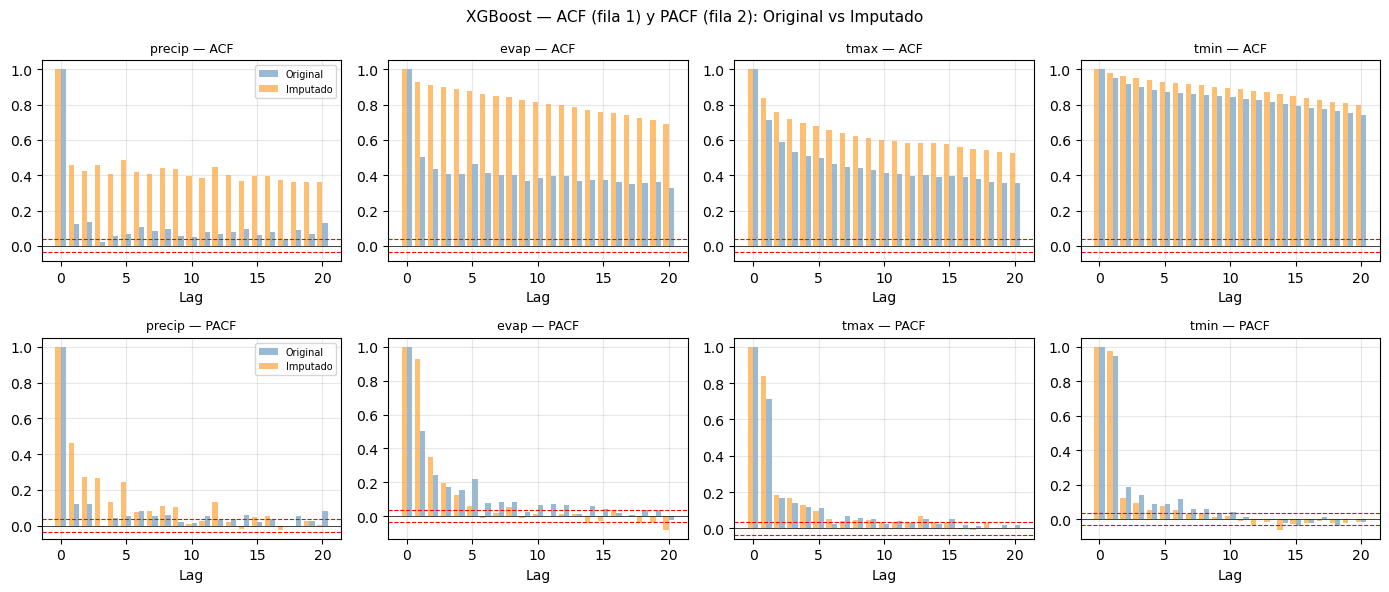

Validación temporal completada.
Metricas unificadas guardadas: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/metrics_xgboost.csv


In [9]:
from statsmodels.tsa.stattools import kpss, acf, pacf
import warnings

VARIABLES_XGB = ["precip", "evap", "tmax", "tmin"]
N_LAGS = 20

print("=== KPSS: Estacionariedad (H₀: estacionaria) ===")
print(f"{'Variable':<8}  {'Stat_orig':<10}  {'p_orig':<8}  {'Stat_imp':<10}  {'p_imp':<8}  {'¿Preserva?'}")
print("─" * 65)

kpss_rows, acf_rows = [], []

for var in VARIABLES_XGB:
    model_var     = models_fitted[var]
    feat_cols_var = get_feature_cols(var)

    # Reconstruir feature engineering por variable (consistente con entrenamiento)
    _df_tv        = pd.concat([df_train, df_val], ignore_index=True)
    _df_tv_fe     = build_features(_df_tv, var, lag_days=FEATURE_LAGS)
    _X_tv         = _df_tv_fe.loc[_df_tv_fe[var].notna(), feat_cols_var]\
                    .fillna(_df_tv_fe[feat_cols_var].median())
    feat_med      = _X_tv.median()

    _df_test_fe   = build_features(df_test, var, lag_days=FEATURE_LAGS)
    X_te          = _df_test_fe[feat_cols_var].fillna(feat_med)
    obs_mask      = _df_test_fe[var].notna()
    y_orig        = _df_test_fe.loc[obs_mask, var].values[:5000]
    y_pred        = model_var.predict(X_te.loc[obs_mask]).astype(float)[:5000]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat_o, p_o, *_ = kpss(y_orig, regression="c", nlags="auto")
        stat_i, p_i, *_ = kpss(y_pred, regression="c", nlags="auto")
    preserva = bool((p_o > 0.05) == (p_i > 0.05))
    ok = "✓ Sí" if preserva else "✗ No"
    print(f"{var:<8}  {stat_o:<10.4f}  {p_o:<8.4f}  {stat_i:<10.4f}  {p_i:<8.4f}  {ok}")
    kpss_rows.append({"modelo": "XGBoost", "variable": var,
                      "stat_orig": round(stat_o, 4), "p_orig": round(p_o, 4),
                      "stat_imp":  round(stat_i, 4), "p_imp":  round(p_i, 4),
                      "preserva_estacionariedad": preserva})

    n_s   = min(len(y_orig), 3000)
    acf_o = acf(y_orig[:n_s],  nlags=N_LAGS, fft=True)
    acf_i = acf(y_pred[:n_s],  nlags=N_LAGS, fft=True)
    pac_o = pacf(y_orig[:n_s], nlags=N_LAGS)
    pac_i = pacf(y_pred[:n_s], nlags=N_LAGS)
    for lag in range(N_LAGS + 1):
        acf_rows.append({"modelo": "XGBoost", "variable": var, "lag": lag,
                         "acf_orig":  round(float(acf_o[lag]), 4),
                         "acf_imp":   round(float(acf_i[lag]), 4),
                         "pacf_orig": round(float(pac_o[lag]), 4),
                         "pacf_imp":  round(float(pac_i[lag]), 4)})

df_kpss = pd.DataFrame(kpss_rows)
df_kpss.to_csv(REPORTS_DIR / "kpss_xgboost.csv", index=False)
print(f"\nKPSS guardado: {REPORTS_DIR / 'kpss_xgboost.csv'}")

df_acf = pd.DataFrame(acf_rows)
df_acf.to_csv(REPORTS_DIR / "acf_pacf_xgboost.csv", index=False)
print(f"ACF/PACF guardado: {REPORTS_DIR / 'acf_pacf_xgboost.csv'}")

fig, axes = plt.subplots(2, len(VARIABLES_XGB), figsize=(14, 6))
fig.suptitle("XGBoost — ACF (fila 1) y PACF (fila 2): Original vs Imputado", fontsize=11)

for fi, var in enumerate(VARIABLES_XGB):
    sub  = df_acf[df_acf["variable"] == var].sort_values("lag")
    lags = sub["lag"].values
    ci   = 1.96 / (3000 ** 0.5)
    for row, (co, ci2, lbl) in enumerate([
            ("acf_orig", "acf_imp", "ACF"), ("pacf_orig", "pacf_imp", "PACF")]):
        ax = axes[row, fi]
        ax.bar(lags, sub[co],  alpha=0.55, color="steelblue",  label="Original", width=0.4,  align="edge")
        ax.bar(lags, sub[ci2], alpha=0.55, color="darkorange", label="Imputado", width=-0.4, align="edge")
        ax.axhline(0,   color="black", lw=0.5)
        ax.axhline( ci, color="red",   lw=0.8, ls="--")
        ax.axhline(-ci, color="red",   lw=0.8, ls="--")
        ax.set_title(f"{var} — {lbl}", fontsize=9)
        ax.set_xlabel("Lag"); ax.grid(alpha=0.3)
        if fi == 0: ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "figuras" / "xgboost_kpss_acf.png", dpi=120, bbox_inches="tight")
plt.show()
print("Validación temporal completada.")



## 7 — Resumen de métricas y guardado

In [14]:
metrics_xgb = pd.DataFrame(xgb_results)

# Merge KPSS columns (calculadas en celda anterior)
kpss_slim = df_kpss[['variable','stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad']].copy()
metrics_xgb = metrics_xgb.merge(kpss_slim, on='variable', how='left')
metrics_xgb.to_csv(REPORTS_DIR / 'metrics_xgboost.csv', index=False)

print(f'Modelo: {MODEL_NAME}')
print(f'MCAR rate: {MCAR_RATE*100:.0f}%')
print('')
print('── Métricas de error y ajuste ──')
display(
    metrics_xgb[['variable','n_mcar','rmse','mae','mape','r2','nse']]
    .set_index('variable').round(4)
)
print('')
print('── Estacionariedad KPSS ──')
display(
    metrics_xgb[['variable','stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad']]
    .set_index('variable').round(4)
)
print(f'\nGuardado en: {REPORTS_DIR / "metrics_xgboost.csv"}')

Modelo: XGBoost
MCAR rate: 20%

── Métricas de error y ajuste ──


,n_mcar,rmse,mae,mape,r2,nse
variable,,,,,,
precip,48075,0.0208,0.0069,2.659381e+07,0.1394,0.1394
evap,24803,0.0559,0.0381,1.817171e+05,0.6891,0.6891
tmax,47177,0.4183,0.3021,8.828380e+01,0.8271,0.8271
tmin,47177,0.2761,0.1986,5.690260e+01,0.9265,0.9265



── Estacionariedad KPSS ──


,stat_orig,p_orig,stat_imp,p_imp,preserva_estacionariedad
variable,,,,,
precip,1.5165,0.0100,0.6277,0.0201,True
evap,1.2476,0.0100,1.1833,0.0100,True
tmax,0.4483,0.0563,0.2961,0.1000,True
tmin,0.5365,0.0335,0.4968,0.0424,True



Guardado en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/metrics_xgboost.csv


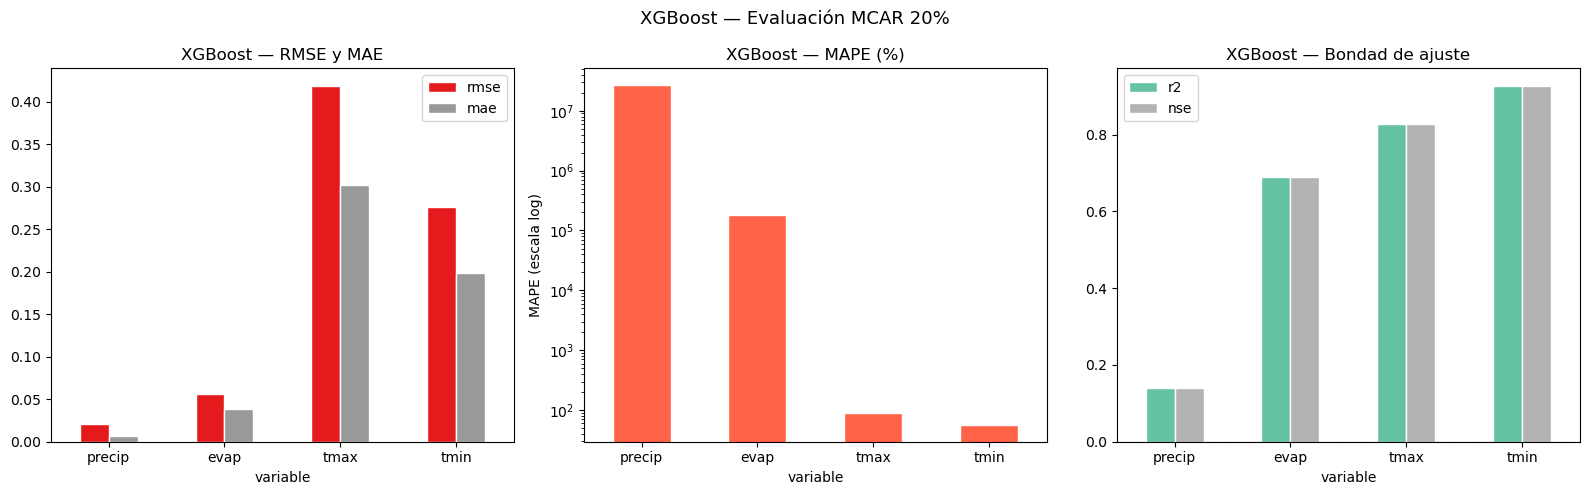


── Preservación de estacionariedad (KPSS) ──


,veredicto_orig,veredicto_imp,preserva
variable,,,
precip,No estacionaria,No estacionaria,✓ Sí
evap,No estacionaria,No estacionaria,✓ Sí
tmax,Estacionaria,Estacionaria,✓ Sí
tmin,No estacionaria,No estacionaria,✓ Sí


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_xgb.set_index('variable')[['rmse','mae']].plot(
    kind='bar', ax=axes[0], colormap='Set1', edgecolor='white'
)
axes[0].set_title(f'{MODEL_NAME} — RMSE y MAE')
axes[0].tick_params(axis='x', rotation=0)

metrics_xgb.set_index('variable')[['mape']].plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='white', legend=False
)
axes[1].set_title(f'{MODEL_NAME} — MAPE (%)')
axes[1].set_yscale('log')
axes[1].set_ylabel('MAPE (escala log)')
axes[1].tick_params(axis='x', rotation=0)

metrics_xgb.set_index('variable')[['r2','nse']].plot(
    kind='bar', ax=axes[2], colormap='Set2', edgecolor='white'
)
axes[2].set_title(f'{MODEL_NAME} — Bondad de ajuste')
axes[2].axhline(0, color='black', lw=0.8, ls='--')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle(f'{MODEL_NAME} — Evaluación MCAR 20%', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xgboost_metricas.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla resumen de estacionariedad KPSS
print('\n── Preservación de estacionariedad (KPSS) ──')
kpss_display = df_kpss[['variable','p_orig','p_imp','preserva_estacionariedad']].copy()
kpss_display['veredicto_orig'] = kpss_display['p_orig'].apply(lambda p: 'Estacionaria' if p > 0.05 else 'No estacionaria')
kpss_display['veredicto_imp']  = kpss_display['p_imp'].apply( lambda p: 'Estacionaria' if p > 0.05 else 'No estacionaria')
kpss_display['preserva'] = kpss_display['preserva_estacionariedad'].map({True: '✓ Sí', False: '✗ No'})
display(kpss_display[['variable','veredicto_orig','veredicto_imp','preserva']].set_index('variable'))

## 8 — Análisis de resultados

### Fortalezas de XGBoost para imputación
- Captura relaciones no lineales entre variables (covariables cruzadas).
- Robusto ante outliers gracias al boosting por gradiente.
- No requiere supuesto de estacionariedad.
- Con lags y covariables contemporáneas aprovecha la correlación tmax–evap (r=0.572 del EDA).

### Limitaciones
- Requiere definir manualmente el lag horizon; no modela dependencias temporales largas de forma nativa.
- La imputación de `evap` es más difícil: faltantes estructurales (rachas de ~3.6 años), no MCAR.
- No genera intervalos de incertidumbre sin técnicas adicionales (e.g. quantile regression).

### Interpretación de métricas
- `precip` y `evap` en espacio MinMaxScaler [0,1]: RMSE típico esperado < 0.1 es buena referencia.
- `tmax` y `tmin` en z-scores (StandardScaler): RMSE < 0.5 equivale a ~2.5 °C de error.
- NSE > 0.6 indica buen ajuste; NSE > 0.8 es excelente para series hidrometeorológicas.
- **KPSS:** XGBoost imputa posición a posición sin modelar explícitamente la dependencia temporal, lo que puede alterar la estructura de autocorrelación. Si `preserva_estacionariedad = False` en alguna variable, indica que el modelo introduce o destruye tendencia.
- **ACF/PACF:** se espera que los lags bajos (1-7) sean similares entre original e imputado; diferencias en lags medios/altos indican pérdida de memoria temporal en la serie imputada.